# K-Means — Attrition Clustering

## K-Means Implementation (From Scratch)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import uniform
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix as cm_func, silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

In [21]:
# Euclidean distance
def euclidean(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2))

# Initialize centroids
def init_centroids(X, n_clusters, random_state=42):
    np.random.seed(random_state)
    minpoint, maxpoint = np.min(X, axis=0), np.max(X, axis=0)
    centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
    return centroids

def calculateClass(X, centroids, n_clusters):
    sorted_x = [[] for _ in range(n_clusters)]
    labels = np.zeros(len(X), dtype=int)
    for idx, x in enumerate(X):
        dists = [euclidean(x, centroid) for centroid in centroids]
        centroid_idx = np.argmin(dists)
        sorted_x[centroid_idx].append(x)
        labels[idx] = centroid_idx
    sorted_x = [np.array(cluster) if len(cluster) > 0 else np.empty((0, X.shape[1])) for cluster in sorted_x]
    return sorted_x, labels

# After that, we use the result to adjust the current centroid.
# Reassign centroids as the mean of the points belonging to them.
def adjustCentroid(sorted_x, centroids):
    prev_centroids = centroids
    new_centroids = []
    for i, cluster in enumerate(sorted_x):
        if len(cluster) > 0:
            new_centroids.append(np.mean(cluster, axis=0))
        else:
            new_centroids.append(prev_centroids[i])
    return np.array(new_centroids)

'''
Training loop: 
    1. calculateClasses
    2. adjustCentroid
    3. repeat until converged
''' 
def train(X, n_clusters, max_iters=300, random_state=42):
    centroids = init_centroids(X, n_clusters, random_state)
    labels = None
    for iteration in range(max_iters):
        sorted_x, labels = calculateClass(X, centroids, n_clusters)
        new_centroids = adjustCentroid(sorted_x, centroids)
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration + 1}")
            break
        centroids = new_centroids
    else:
        print(f"Reached max iterations ({max_iters})")

    inertia = sum(euclidean(X[i], centroids[labels[i]])**2 for i in range(len(X)))
    return centroids, labels, sorted_x, inertia

# Plotting
def showplotwithclass_2d(sorted_x_2d, centroids_2d, title="K-Means Clusters"):
    plt.figure(figsize=(9, 3.5))
    colors = plt.cm.tab20.colors
    for i, cluster_points in enumerate(sorted_x_2d):
        if len(cluster_points) == 0:
            continue
        cluster_points = np.array(cluster_points)
        plt.plot(cluster_points[:, 0], cluster_points[:, 1],
                 marker='o', linestyle='', color=colors[i % len(colors)],
                 label=f"Cluster {i}")
    centroids_arr = np.array(centroids_2d)
    plt.plot(centroids_arr[:, 0], centroids_arr[:, 1],
             'k+', markersize=15, markeredgewidth=3, label="Centroids")
    plt.xlabel("Component 1", fontsize=10)
    plt.ylabel("Component 2", fontsize=10)
    plt.title(title, fontsize=12)
    plt.legend(fontsize=10)
    plt.show()

## Load & Prepare Data

In [23]:
df = pd.read_csv('../data/processed_data.csv')

attrition_raw = df['Attrition'].values
attrition_binary = (attrition_raw == attrition_raw.max()).astype(int)
X = df.drop(columns=['Attrition']).values
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"Original dataset: {X.shape}")
print(f"Attrition distribution — real data (NOT used in clustering):")
print(f"  No Attrition (0): {np.sum(attrition_binary == 0)}")
print(f"  Attrition    (1): {np.sum(attrition_binary == 1)}")

pca_95 = PCA(n_components=0.95, random_state=42)
X_pca = pca_95.fit_transform(X)

n_components = X_pca.shape[1]
cumvar = np.cumsum(pca_95.explained_variance_ratio_)
print(f"\nPCA 95% variance: {X.shape[1]} features → {n_components} components")
print(f"Explained variance retained: {pca_95.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nVariance per component:")
for i, (var, cum) in enumerate(zip(pca_95.explained_variance_ratio_, cumvar)):
    print(f"  PC{i+1:>2}: {var*100:5.2f}%  (cumulative: {cum*100:6.2f}%)")

X_vis = X_pca[:, :2]  

print(f"\nVisualization axes: PC1 ({pca_95.explained_variance_ratio_[0]*100:.2f}%) "
      f"+ PC2 ({pca_95.explained_variance_ratio_[1]*100:.2f}%)")
print("\nRunning t-SNE on PCA-reduced data...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)   # shape: (n_samples, 2)
print(f"t-SNE output shape: {X_tsne.shape}")

Original dataset: (1470, 36)
Attrition distribution — real data (NOT used in clustering):
  No Attrition (0): 1232
  Attrition    (1): 238

PCA 95% variance: 36 features → 29 components
Explained variance retained: 95.73%

Variance per component:
  PC 1: 12.71%  (cumulative:  12.71%)
  PC 2: 10.61%  (cumulative:  23.32%)
  PC 3:  5.40%  (cumulative:  28.72%)
  PC 4:  5.10%  (cumulative:  33.82%)
  PC 5:  4.67%  (cumulative:  38.49%)
  PC 6:  4.40%  (cumulative:  42.89%)
  PC 7:  4.06%  (cumulative:  46.94%)
  PC 8:  3.40%  (cumulative:  50.34%)
  PC 9:  3.20%  (cumulative:  53.54%)
  PC10:  3.02%  (cumulative:  56.56%)
  PC11:  2.94%  (cumulative:  59.50%)
  PC12:  2.91%  (cumulative:  62.41%)
  PC13:  2.81%  (cumulative:  65.22%)
  PC14:  2.77%  (cumulative:  67.98%)
  PC15:  2.72%  (cumulative:  70.71%)
  PC16:  2.72%  (cumulative:  73.42%)
  PC17:  2.61%  (cumulative:  76.04%)
  PC18:  2.53%  (cumulative:  78.57%)
  PC19:  2.43%  (cumulative:  81.00%)
  PC20:  2.11%  (cumulative:  8

## Run K-Means

In [ ]:
# Train K-Means on PCA-reduced data (95% variance)
centroids, labels, sorted_x, inertia = train(X_pca, n_clusters=2, random_state=42)

print(f"K-Means Clustering with K=2 (on {X_pca.shape[1]} PCA components)")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"\nCluster distribution:")
for k in range(2):
    count = np.sum(labels == k)
    print(f"  Cluster {k}: {count} samples ({count/len(labels)*100:.1f}%)")


Converged at iteration 14
K-Means Clustering with K=2 (on 29 PCA components)
Inertia (WCSS): 46423.59

Cluster distribution:
  Cluster 0: 477 samples (32.4%)
  Cluster 1: 993 samples (67.6%)


## Evaluation on Test Set

In [24]:
def map_clusters_to_labels(cluster_labels, true_labels):
    acc_1 = np.mean(cluster_labels == true_labels)
    flipped = 1 - cluster_labels
    acc_2 = np.mean(flipped == true_labels)
    if acc_2 > acc_1:
        return flipped, acc_2
    return cluster_labels, acc_1

predicted, accuracy = map_clusters_to_labels(labels, attrition_binary)

# Confusion Matrix
tp = np.sum((predicted == 1) & (attrition_binary == 1))
tn = np.sum((predicted == 0) & (attrition_binary == 0))
fp = np.sum((predicted == 1) & (attrition_binary == 0))
fn = np.sum((predicted == 0) & (attrition_binary == 1))

precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity= tn / (tn + fp) if (tn + fp) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
sil_score  = silhouette_score(X_pca, labels)  # silhouette in PCA space (same as training space)

print("=" * 45)
print("  K-Means (K=2) — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:        {accuracy:.4f}")
print(f"  Precision:       {precision:.4f}")
print(f"  Recall:          {recall:.4f}")
print(f"  Specificity:     {specificity:.4f}")
print(f"  F1 Score:        {f1:.4f}")
print(f"  Inertia (WCSS):  {inertia:.2f}")
print(f"  Silhouette Score:{sil_score:.4f}")
print("=" * 45)
print(f"\n  Confusion Matrix:")
print(f"                Predicted")
print(f"                No(0)  Yes(1)")
print(f"  Actual No(0)  {tn:<6} {fp}")
print(f"  Actual Yes(1) {fn:<6} {tp}")

print(f"\n  Attrition Rate per Cluster:")
for k in range(2):
    cluster_mask = labels == k
    attrition_rate = np.mean(attrition_binary[cluster_mask]) * 100
    print(f"    Cluster {k}: {attrition_rate:.1f}% attrition "
          f"({np.sum(attrition_binary[cluster_mask])}/{np.sum(cluster_mask)} employees)")


  K-Means (K=2) — Evaluation Results
  Accuracy:        0.5680
  Precision:       0.0839
  Recall:          0.1681
  Specificity:     0.6453
  F1 Score:        0.1119
  Inertia (WCSS):  46423.59
  Silhouette Score:0.0922

  Confusion Matrix:
                Predicted
                No(0)  Yes(1)
  Actual No(0)  795    437
  Actual Yes(1) 198    40

  Attrition Rate per Cluster:
    Cluster 0: 8.4% attrition (40/477 employees)
    Cluster 1: 19.9% attrition (198/993 employees)


## Confusion Matrix

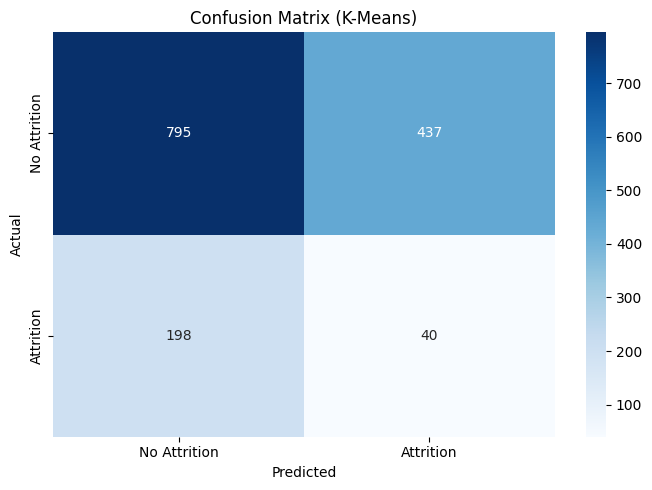

In [25]:
cm_kmeans = cm_func(attrition_binary, predicted)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (K-Means)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Cluster Visualization (PCA 2D)

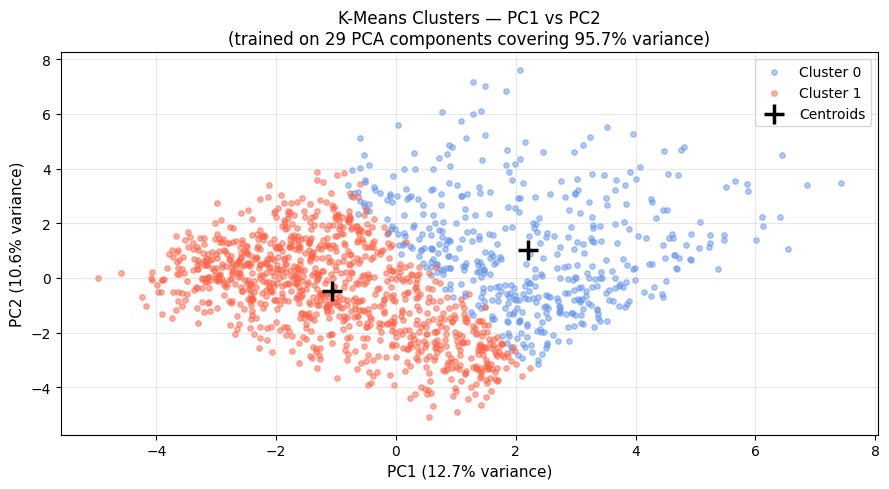

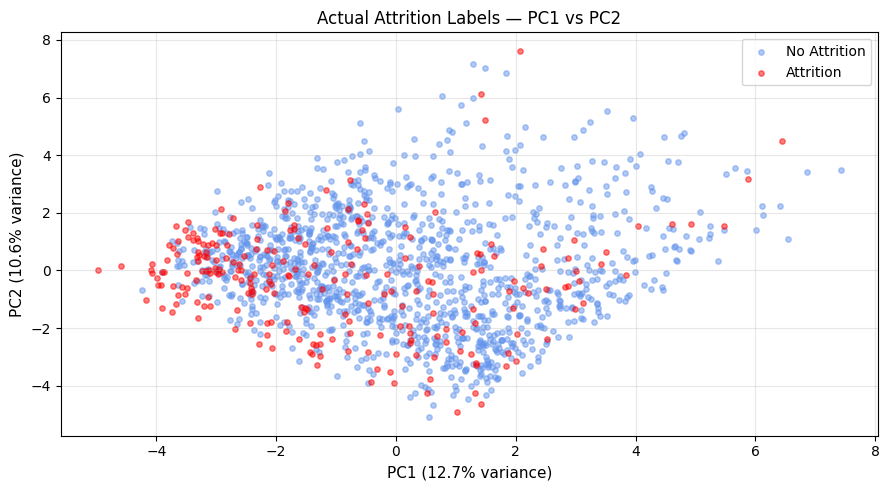

Visualization covers: PC1 12.7% + PC2 10.6% = 23.3% of total variance


In [26]:
centroids_vis = centroids[:, :2]
sorted_x_vis  = [X_vis[labels == k] for k in range(2)]

pc1_var = pca_95.explained_variance_ratio_[0] * 100
pc2_var = pca_95.explained_variance_ratio_[1] * 100

plt.figure(figsize=(9, 5))
colors = ['cornflowerblue', 'tomato']
for k in range(2):
    pts = sorted_x_vis[k]
    plt.scatter(pts[:, 0], pts[:, 1], c=colors[k], alpha=0.5, s=15, label=f"Cluster {k}")
plt.scatter(centroids_vis[:, 0], centroids_vis[:, 1],
            c='black', marker='+', s=200, linewidths=2.5, label="Centroids")
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)", fontsize=11)
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)", fontsize=11)
plt.title(f"K-Means Clusters — PC1 vs PC2\n"
          f"(trained on {X_pca.shape[1]} PCA components covering "
          f"{pca_95.explained_variance_ratio_.sum()*100:.1f}% variance)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
for label_val, color, name in [(0, 'cornflowerblue', 'No Attrition'), (1, 'red', 'Attrition')]:
    mask = attrition_binary == label_val
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1], c=color, alpha=0.5, s=15, label=name)
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)", fontsize=11)
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)", fontsize=11)
plt.title("Actual Attrition Labels — PC1 vs PC2", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Visualization covers: PC1 {pc1_var:.1f}% + PC2 {pc2_var:.1f}% "
      f"= {pc1_var+pc2_var:.1f}% of total variance")


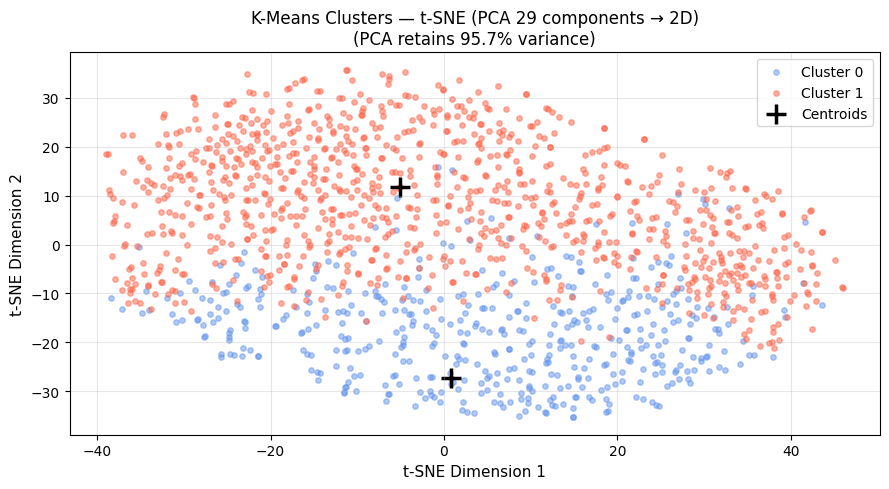

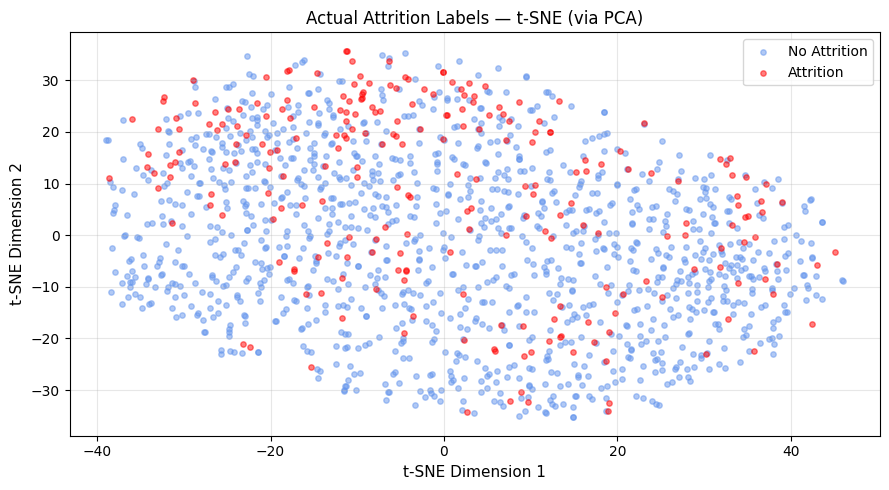

In [27]:
centroids_tsne = np.array([
    X_tsne[np.argmin(pairwise_distances([c], X_pca)[0])]   # closest real point
    for c in centroids
])

sorted_x_tsne = [X_tsne[labels == k] for k in range(2)]

plt.figure(figsize=(9, 5))
colors = ['cornflowerblue', 'tomato']
for k in range(2):
    pts = sorted_x_tsne[k]
    plt.scatter(pts[:, 0], pts[:, 1], c=colors[k], alpha=0.5, s=15, label=f"Cluster {k}")
plt.scatter(centroids_tsne[:, 0], centroids_tsne[:, 1],
            c='black', marker='+', s=200, linewidths=2.5, label="Centroids")
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.title(f"K-Means Clusters — t-SNE (PCA {X_pca.shape[1]} components → 2D)\n"
          f"(PCA retains {pca_95.explained_variance_ratio_.sum()*100:.1f}% variance)",
          fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Attrition ground-truth plot ───────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for label_val, color, name in [(0, 'cornflowerblue', 'No Attrition'), (1, 'red', 'Attrition')]:
    mask = attrition_binary == label_val
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, alpha=0.5, s=15, label=name)
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.title("Actual Attrition Labels — t-SNE (via PCA)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Sklearn K-Means — Comparison

In [ ]:
# Sklearn K-Means also trained on PCA-reduced data for a fair comparison
sklearn_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
sklearn_labels = sklearn_kmeans.fit_predict(X_pca)
sklearn_pred, sklearn_acc = map_clusters_to_labels(sklearn_labels, attrition_binary)

# Confusion Matrix
tp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 1))
tn_sk = np.sum((sklearn_pred == 0) & (attrition_binary == 0))
fp_sk = np.sum((sklearn_pred == 1) & (attrition_binary == 0))
fn_sk = np.sum((sklearn_pred == 0) & (attrition_binary == 1))

prec_sk  = tp_sk / (tp_sk + fp_sk) if (tp_sk + fp_sk) > 0 else 0
rec_sk   = tp_sk / (tp_sk + fn_sk) if (tp_sk + fn_sk) > 0 else 0
spec_sk  = tn_sk / (tn_sk + fp_sk) if (tn_sk + fp_sk) > 0 else 0
f1_sk    = 2 * prec_sk * rec_sk / (prec_sk + rec_sk) if (prec_sk + rec_sk) > 0 else 0
sil_sk   = silhouette_score(X_pca, sklearn_labels)

print("=" * 55)
print("  K-Means Comparison: From Scratch vs Sklearn (K=2)")
print("=" * 55)
print(f"  {'Metric':<15} {'From-Scratch':<15} {'Sklearn':<15}")
print(f"  {'-'*45}")
print(f"  {'Accuracy':<15} {accuracy:<15.4f} {sklearn_acc:<15.4f}")
print(f"  {'Precision':<15} {precision:<15.4f} {prec_sk:<15.4f}")
print(f"  {'Recall':<15} {recall:<15.4f} {rec_sk:<15.4f}")
print(f"  {'Specificity':<15} {specificity:<15.4f} {spec_sk:<15.4f}")
print(f"  {'F1 Score':<15} {f1:<15.4f} {f1_sk:<15.4f}")
print(f"  {'Inertia':<15} {inertia:<15.2f} {sklearn_kmeans.inertia_:<15.2f}")
print(f"  {'Silhouette':<15} {sil_score:<15.4f} {sil_sk:<15.4f}")
print("=" * 55)


  K-Means Comparison: From Scratch vs Sklearn (K=2)
  Metric          From-Scratch    Sklearn        
  ---------------------------------------------
  Accuracy        0.5680          0.5122         
  Precision       0.0839          0.2017         
  Recall          0.1681          0.6807         
  Specificity     0.6453          0.4797         
  F1 Score        0.1119          0.3112         
  Inertia         46423.59        45727.30       
  Silhouette      0.0922          0.0948         
